In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)

# ৫০ জন সরকারি কর্মচারীর সিমুলেটেড ডেটা
n = 50

grade    = np.random.randint(5, 11, n)          # গ্রেড ৫–১০
exp      = np.random.randint(1, 20, n)          # অভিজ্ঞতা ১–২০ বছর
age      = exp + np.random.randint(22, 28, n)   # বয়স
training = np.random.randint(0, 5, n)           # প্রশিক্ষণ সংখ্যা

# বেতন সূত্র (বাস্তবসম্মত)
beton = (
    8000
    + (11 - grade) * 4500     # গ্রেড যত কম, বেতন তত বেশি
    + exp * 1800               # অভিজ্ঞতা প্রতি বছর
    + training * 600           # প্রশিক্ষণ বোনাস
    + np.random.normal(0, 2000, n)  # বাস্তব বৈচিত্র্য
).round(0)

df = pd.DataFrame({
    "গ্রেড": grade,
    "অভিজ্ঞতা": exp,
    "বয়স": age,
    "প্রশিক্ষণ": training,
    "বেতন": beton.astype(int)
})

print("=== ডেটাসেট (প্রথম ৫ সারি) ===")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\n=== সারসংক্ষেপ ===")
print(df.describe().round(0))

=== ডেটাসেট (প্রথম ৫ সারি) ===
   গ্রেড  অভিজ্ঞতা  বয়স  প্রশিক্ষণ   বেতন
0      8        14    38          1  49774
1      9        18    40          1  47147
2      7         9    33          4  45276
3      9         2    28          0  24549
4      9        15    38          4  50330

Shape: (50, 5)

=== সারসংক্ষেপ ===
       গ্রেড  অভিজ্ঞতা  বয়স  প্রশিক্ষণ     বেতন
count   50.0      50.0  50.0       50.0     50.0
mean     8.0      10.0  35.0        2.0  42976.0
std      2.0       5.0   5.0        1.0  12966.0
min      5.0       1.0  25.0        0.0  16156.0
25%      7.0       7.0  31.0        0.0  31530.0
50%      8.0      10.0  35.0        2.0  47129.0
75%      9.0      15.0  39.0        3.0  50988.0
max     10.0      19.0  44.0        4.0  67008.0


C:\Users\User\AppData\Local\Temp\ipykernel_3412\3925438174.py:54: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3925438174.py:54: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3925438174.py:54: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3925438174.py:54: UserWarning: Glyph 2468 (\N{BENGALI LETTER TA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3925438174.py:54: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3925438174.py:54: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Te

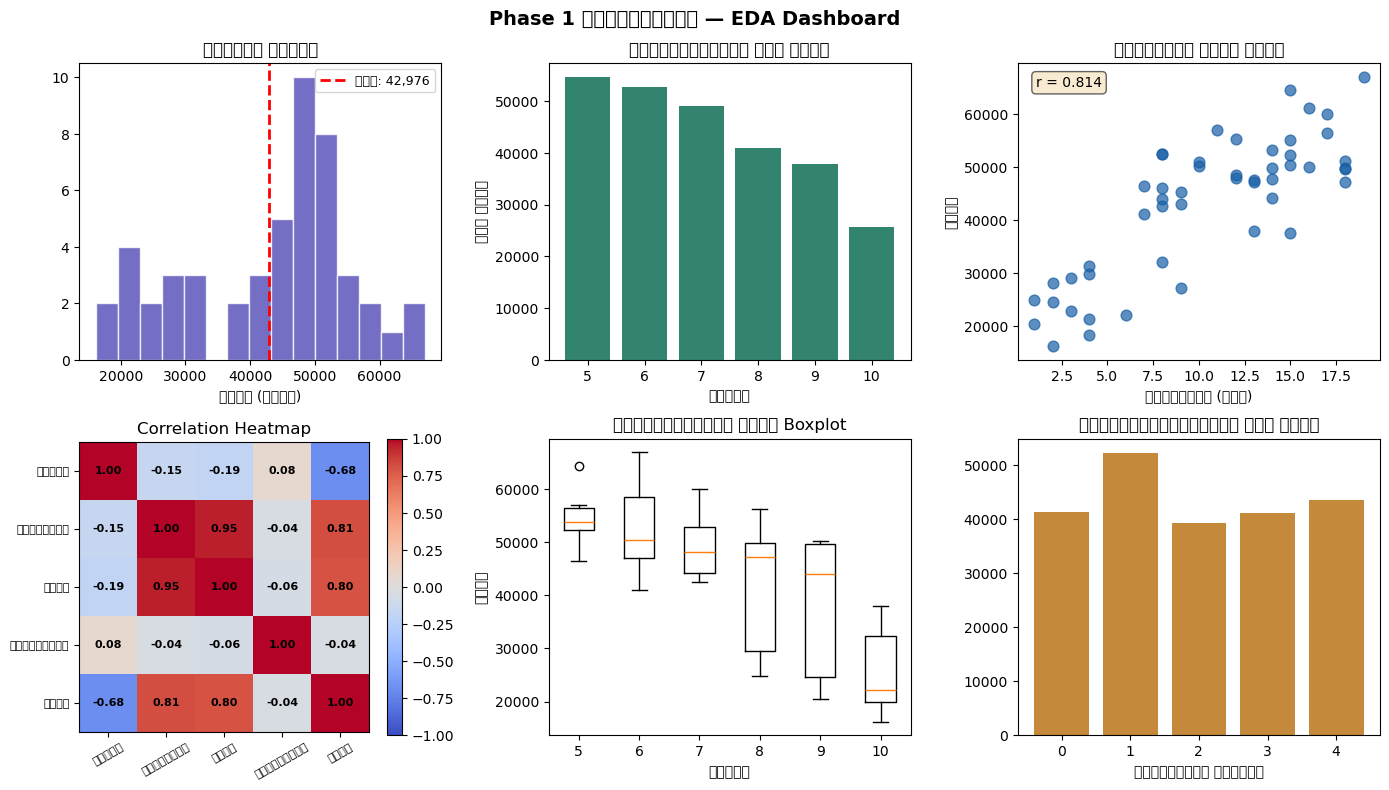

eda_dashboard.png সেভ হয়েছে (IEEE paper Figure 1)


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Phase 1 ক্যাপস্টোন — EDA Dashboard", fontsize=14, fontweight="bold")

# ১. বেতনের বিতরণ
axes[0,0].hist(df["বেতন"], bins=15, color="#534AB7", alpha=0.8, edgecolor="white")
axes[0,0].axvline(df["বেতন"].mean(), color="red", linestyle="--", linewidth=2, label=f'গড়: {df["বেতন"].mean():,.0f}')
axes[0,0].set_title("বেতনের বিতরণ")
axes[0,0].set_xlabel("বেতন (টাকা)")
axes[0,0].legend(fontsize=9)

# ২. গ্রেড বনাম বেতন
grade_avg = df.groupby("গ্রেড")["বেতন"].mean()
axes[0,1].bar(grade_avg.index, grade_avg.values, color="#0F6E56", alpha=0.85)
axes[0,1].set_title("গ্রেডভিত্তিক গড় বেতন")
axes[0,1].set_xlabel("গ্রেড")
axes[0,1].set_ylabel("গড় বেতন")

# ৩. অভিজ্ঞতা বনাম বেতন (Scatter)
axes[0,2].scatter(df["অভিজ্ঞতা"], df["বেতন"], color="#185FA5", alpha=0.7, s=60)
axes[0,2].set_title("অভিজ্ঞতা বনাম বেতন")
axes[0,2].set_xlabel("অভিজ্ঞতা (বছর)")
axes[0,2].set_ylabel("বেতন")
r = np.corrcoef(df["অভিজ্ঞতা"], df["বেতন"])[0,1]
axes[0,2].text(0.05, 0.92, f"r = {r:.3f}", transform=axes[0,2].transAxes,
               fontsize=10, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))

# ৪. Correlation Heatmap
numeric_df = df[["গ্রেড","অভিজ্ঞতা","বয়স","প্রশিক্ষণ","বেতন"]]
corr = numeric_df.corr()
im = axes[1,0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
cols = ["গ্রেড","অভিজ্ঞতা","বয়স","প্রশিক্ষণ","বেতন"]
axes[1,0].set_xticks(range(5)); axes[1,0].set_xticklabels(cols, rotation=30, fontsize=8)
axes[1,0].set_yticks(range(5)); axes[1,0].set_yticklabels(cols, fontsize=8)
for i in range(5):
    for j in range(5):
        axes[1,0].text(j, i, f"{corr.iloc[i,j]:.2f}",
                       ha="center", va="center", fontsize=8, fontweight="bold")
plt.colorbar(im, ax=axes[1,0])
axes[1,0].set_title("Correlation Heatmap")

# ৫. Boxplot — গ্রেডভিত্তিক বেতন বিতরণ
grade_groups = [df[df["গ্রেড"]==g]["বেতন"].values for g in sorted(df["গ্রেড"].unique())]
axes[1,1].boxplot(grade_groups, labels=sorted(df["গ্রেড"].unique()))
axes[1,1].set_title("গ্রেডভিত্তিক বেতন Boxplot")
axes[1,1].set_xlabel("গ্রেড")
axes[1,1].set_ylabel("বেতন")

# ৬. প্রশিক্ষণ বনাম বেতন
training_avg = df.groupby("প্রশিক্ষণ")["বেতন"].mean()
axes[1,2].bar(training_avg.index, training_avg.values, color="#BA7517", alpha=0.85)
axes[1,2].set_title("প্রশিক্ষণভিত্তিক গড় বেতন")
axes[1,2].set_xlabel("প্রশিক্ষণ সংখ্যা")

plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()
print("eda_dashboard.png সেভ হয়েছে (IEEE paper Figure 1)")

In [4]:
# Feature ও Target আলাদা করা
X = df[["গ্রেড","অভিজ্ঞতা","বয়স","প্রশিক্ষণ"]]
y = df["বেতন"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train সেট: {X_train.shape[0]} টি নমুনা")
print(f"Test সেট:  {X_test.shape[0]} টি নমুনা")
print(f"\nFeature গড় (scaled): {X_train_sc.mean(axis=0).round(4)}")
print(f"Feature std (scaled): {X_train_sc.std(axis=0).round(4)}")

Train সেট: 40 টি নমুনা
Test সেট:  10 টি নমুনা

Feature গড় (scaled): [-0.  0.  0.  0.]
Feature std (scaled): [1. 1. 1. 1.]


In [5]:
# মডেল প্রশিক্ষণ
model = LinearRegression()
model.fit(X_train_sc, y_train)

# পূর্বাভাস
y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

# মেট্রিক
train_r2 = r2_score(y_train, y_pred_train)
test_r2  = r2_score(y_test,  y_pred_test)
mae      = mean_absolute_error(y_test, y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=" * 45)
print("   সরকারি বেতন প্রেডিক্টর — ফলাফল")
print("=" * 45)
print(f"Train R²:  {train_r2:.4f}")
print(f"Test R²:   {test_r2:.4f}")
print(f"MAE:       {mae:,.0f} টাকা")
print(f"RMSE:      {rmse:,.0f} টাকা")
print(f"\nOverfitting: {'নেই ✓' if abs(train_r2-test_r2) < 0.05 else 'আছে ⚠'}")

# Feature importance
feature_names = ["গ্রেড","অভিজ্ঞতা","বয়স","প্রশিক্ষণ"]
coeffs = model.coef_
print("\n--- Feature Importance (coefficient) ---")
for name, coef in sorted(zip(feature_names, coeffs),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:10s}: {coef:+,.0f} টাকা")

   সরকারি বেতন প্রেডিক্টর — ফলাফল
Train R²:  0.9784
Test R²:   0.9894
MAE:       926 টাকা
RMSE:      1,171 টাকা

Overfitting: নেই ✓

--- Feature Importance (coefficient) ---
  অভিজ্ঞতা  : +9,343 টাকা
  গ্রেড     : -7,167 টাকা
  প্রশিক্ষণ : +399 টাকা
  বয়স      : +83 টাকা


C:\Users\User\AppData\Local\Temp\ipykernel_3412\3875153858.py:26: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3875153858.py:26: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3875153858.py:26: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3875153858.py:26: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3875153858.py:26: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3412\3875153858.py:26: UserWarning: Glyph 2499 (\N{BENGALI VOWEL SIGN VOCALIC R}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData

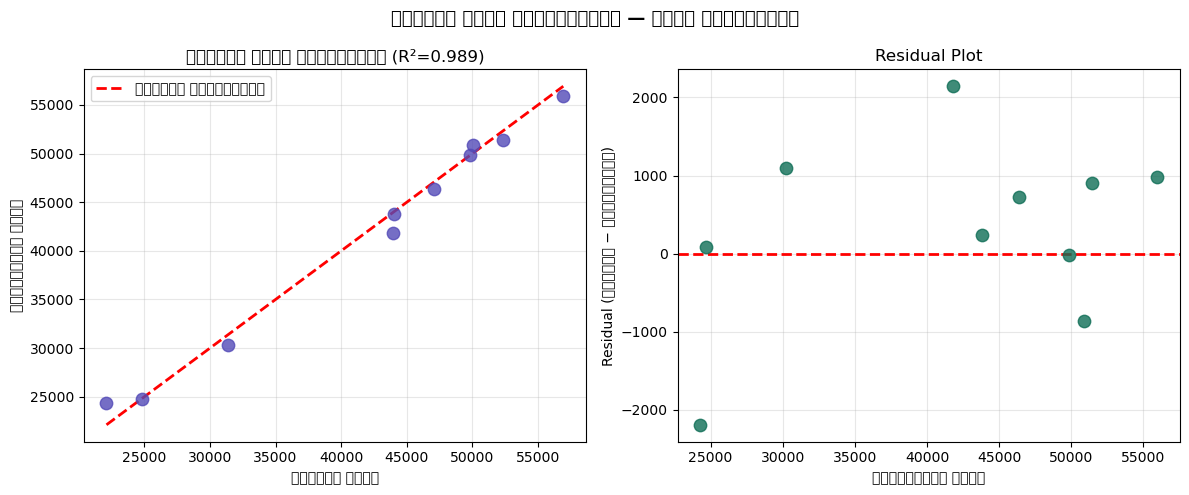

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("সরকারি বেতন প্রেডিক্টর — মডেল মূল্যায়ন",
             fontsize=13, fontweight="bold")

# চার্ট ১: প্রকৃত বনাম পূর্বাভাস
axes[0].scatter(y_test, y_pred_test, color="#534AB7", s=80, alpha=0.8, zorder=3)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             "r--", linewidth=2, label="নিখুঁত পূর্বাভাস")
axes[0].set_xlabel("প্রকৃত বেতন")
axes[0].set_ylabel("পূর্বাভাস বেতন")
axes[0].set_title(f"প্রকৃত বনাম পূর্বাভাস (R²={test_r2:.3f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# চার্ট ২: Residual Plot
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, color="#0F6E56", s=80, alpha=0.8, zorder=3)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("পূর্বাভাস বেতন")
axes[1].set_ylabel("Residual (প্রকৃত − পূর্বাভাস)")
axes[1].set_title("Residual Plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
def beton_predictor(grade, exp, age, training_count):
    """সরকারি কর্মচারীর বেতন পূর্বাভাস দেওয়ার ফাংশন"""
    input_data = np.array([[grade, exp, age, training_count]])
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]

    print("=" * 40)
    print("  সরকারি বেতন প্রেডিক্টর")
    print("=" * 40)
    print(f"  গ্রেড       : {grade}")
    print(f"  অভিজ্ঞতা   : {exp} বছর")
    print(f"  বয়স        : {age} বছর")
    print(f"  প্রশিক্ষণ  : {training_count} টি")
    print(f"  {'─'*36}")
    print(f"  পূর্বাভাস বেতন: {prediction:,.0f} টাকা")
    print(f"  ± {mae:,.0f} টাকা (MAE)")
    print("=" * 40)
    return prediction

# পরীক্ষা — আপনার নিজের তথ্য দিয়ে চেক করুন
beton_predictor(grade=9, exp=7, age=32, training_count=3)

  সরকারি বেতন প্রেডিক্টর
  গ্রেড       : 9
  অভিজ্ঞতা   : 7 বছর
  বয়স        : 32 বছর
  প্রশিক্ষণ  : 3 টি
  ────────────────────────────────────
  পূর্বাভাস বেতন: 31,024 টাকা
  ± 926 টাকা (MAE)


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


31023.502242076374